<h1 style="color:cyan;"> Nike Sales Data Analysis Using Python </h1>


<h2> 🎯 Objective </h2>

The objective of this project is to analyze Nike sales data to identify sales trends, product performance, and regional demand. Using Python data analysis techniques such as data cleaning, exploratory data analysis (EDA), and visualization, the project aims to extract insights that help understand customer purchasing patterns and business profitability.

<h2> 📚 Libraries <h/2>

In [87]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

<h2> 🔍 Source link </h2>
https://www.kaggle.com/datasets/nayakganesh007/nike-sales-uncleaned-dataset

<h2> 📁 Load Dataset </h2>

In [88]:
df = pd.read_csv("Nike_Sales_Uncleaned.csv")

df.head()


,Order_ID,Gender_Category,Product_Line,Product_Name,Size,Units_Sold,MRP,Discount_Applied,Revenue,Order_Date,Sales_Channel,Region,Profit
0,2000,Kids,Training,SuperRep Go,M,NaN,NaN,0.47,0.0,2024-03-09,Online,bengaluru,-770.45
1,2001,Women,Soccer,Tiempo Legend,M,3.0,4957.93,NaN,0.0,2024-07-09,Retail,Hyd,-112.53
2,2002,Women,Soccer,Premier III,M,4.0,NaN,NaN,0.0,NaN,Retail,Mumbai,3337.34
3,2003,Kids,Lifestyle,Blazer Mid,L,NaN,9673.57,NaN,0.0,04-10-2024,Online,Pune,3376.85
4,2004,Kids,Running,React Infinity,XL,NaN,NaN,NaN,0.0,2024/09/12,Retail,Delhi,187.89


In [89]:
df.tail()

,Order_ID,Gender_Category,Product_Line,Product_Name,Size,Units_Sold,MRP,Discount_Applied,Revenue,Order_Date,Sales_Channel,Region,Profit
2495,4495,Kids,Basketball,Kyrie Flytrap,XL,3.0,NaN,NaN,0.0,2025-05-14,Online,Pune,2.97
2496,4496,Men,Basketball,Kyrie Flytrap,L,-1.0,NaN,NaN,0.0,NaN,Online,Hyd,-487.36
2497,4497,Men,Soccer,Tiempo Legend,7,NaN,6647.60,0.52,0.0,02-07-2025,Retail,Bangalore,-918.14
2498,4498,Women,Training,ZoomX Invincible,NaN,4.0,5358.70,NaN,0.0,11-12-2024,Online,Mumbai,3352.29
2499,4499,Women,Running,Air Zoom,M,NaN,5550.99,NaN,0.0,23-11-2024,Retail,Mumbai,2453.57


In [90]:
df.shape


(2500, 13)

In [91]:
df.columns

Index(['Order_ID', 'Gender_Category', 'Product_Line', 'Product_Name', 'Size',
       'Units_Sold', 'MRP', 'Discount_Applied', 'Revenue', 'Order_Date',
       'Sales_Channel', 'Region', 'Profit'],
      dtype='str')

In [92]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2500 entries, 0 to 2499
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Order_ID          2500 non-null   int64  
 1   Gender_Category   2500 non-null   str    
 2   Product_Line      2500 non-null   str    
 3   Product_Name      2500 non-null   str    
 4   Size              1990 non-null   str    
 5   Units_Sold        1265 non-null   float64
 6   MRP               1246 non-null   float64
 7   Discount_Applied  832 non-null    float64
 8   Revenue           2500 non-null   float64
 9   Order_Date        1884 non-null   str    
 10  Sales_Channel     2500 non-null   str    
 11  Region            2500 non-null   str    
 12  Profit            2500 non-null   float64
dtypes: float64(5), int64(1), str(7)
memory usage: 254.0 KB


In [93]:
df.describe()

,Order_ID,Units_Sold,MRP,Discount_Applied,Revenue,Profit
count,2500.000000,1265.000000,1246.000000,832.000000,2500.000000,2500.000000
mean,3194.352400,1.482213,6039.863395,0.631022,274.873716,1376.012848
std,749.972638,1.696947,2315.746826,0.365500,2023.773550,1478.671013
min,2000.000000,-1.000000,2006.630000,0.000000,-7561.590000,-1199.450000
25%,2534.750000,0.000000,4038.902500,0.320000,0.000000,93.532500
50%,3192.500000,2.000000,6110.030000,0.615000,0.000000,1371.385000
75%,3841.250000,3.000000,8022.187500,0.962500,0.000000,2660.645000
max,4499.000000,4.000000,9996.220000,1.250000,37169.350000,3999.210000


<h2> ⁉️ Checking Missing Values </h2> 

In [94]:
# Checking how many missing (null) values are present in each column
df.isnull().sum()

Order_ID               0
Gender_Category        0
Product_Line           0
Product_Name           0
Size                 510
Units_Sold          1235
MRP                 1254
Discount_Applied    1668
Revenue                0
Order_Date           616
Sales_Channel          0
Region                 0
Profit                 0
dtype: int64

In [95]:
# Checking if duplicate rows exist in the dataset
df.duplicated().sum()

np.int64(0)

In [96]:
# Filling missing values only for numerical columns
df['Units_Sold'] = df['Units_Sold'].fillna(0)
df['Size'] = df['Size'].fillna(0)
df['MRP'] = df['MRP'].fillna(0)
df['Discount_Applied'] = df['Discount_Applied'].fillna(0)
df['Revenue'] = df['Revenue'].fillna(0)
df['Profit'] = df['Profit'].fillna(0)

In [97]:
df.isnull().sum()

Order_ID              0
Gender_Category       0
Product_Line          0
Product_Name          0
Size                  0
Units_Sold            0
MRP                   0
Discount_Applied      0
Revenue               0
Order_Date          616
Sales_Channel         0
Region                0
Profit                0
dtype: int64

In [98]:
# Remove rows where Order_Date is missing
df = df.dropna(subset=['Order_Date'])

In [99]:
df.isnull().sum()

Order_ID            0
Gender_Category     0
Product_Line        0
Product_Name        0
Size                0
Units_Sold          0
MRP                 0
Discount_Applied    0
Revenue             0
Order_Date          0
Sales_Channel       0
Region              0
Profit              0
dtype: int64

<h2> Exploratory Data Analysis </h2>

In [11]:
import pandas as pd


df = pd.read_csv("Nike_Sales_Uncleaned.csv")


In [4]:
# Calculate correlation between numerical columns
corr_matrix = df[['Units_Sold','MRP','Revenue','Profit']].corr()

corr_matrix

,Units_Sold,MRP,Revenue,Profit
Units_Sold,1.000000,-0.009495,0.183849,0.008230
MRP,-0.009495,1.000000,0.050900,-0.045981
Revenue,0.183849,0.050900,1.000000,0.002691
Profit,0.008230,-0.045981,0.002691,1.000000


In [5]:
pivot_table = pd.pivot_table(
    df,
    values='Revenue',
    index='Region',
    columns='Sales_Channel',
    aggfunc='sum'
)

pivot_table

Sales_Channel,Online,Retail
Region,,
Bangalore,23776.45,31590.53
Delhi,50108.49,44863.68
Hyd,10224.99,-9578.09
Hyderabad,9656.55,18119.15
Kolkata,94609.41,73991.36
Mumbai,24051.53,70947.54
Pune,64457.56,36719.71
bengaluru,46277.22,1101.36
hyderbad,55020.90,41245.95


In [6]:
# Grouping by Product Line and calculating total revenue
revenue_by_product = df.groupby('Product_Line')['Revenue'].sum()

revenue_by_product

Product_Line
Basketball    155292.42
Lifestyle     148870.70
Running        72075.95
Soccer        115392.33
Training      195552.89
Name: Revenue, dtype: float64

In [7]:
pivot_table = pd.pivot_table(
    df,
    values='Revenue',
    index='Region',
    columns='Sales_Channel',
    aggfunc='sum'
)

pivot_table

Sales_Channel,Online,Retail
Region,,
Bangalore,23776.45,31590.53
Delhi,50108.49,44863.68
Hyd,10224.99,-9578.09
Hyderabad,9656.55,18119.15
Kolkata,94609.41,73991.36
Mumbai,24051.53,70947.54
Pune,64457.56,36719.71
bengaluru,46277.22,1101.36
hyderbad,55020.90,41245.95


In [8]:
df[['Revenue','Profit']].agg(['sum','mean','max','min'])

,Revenue,Profit
sum,687184.290000,3.440032e+06
mean,274.873716,1.376013e+03
max,37169.350000,3.999210e+03
min,-7561.590000,-1.199450e+03


<h2> 📈 Visual Analysis </h2>

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns

<h2 style="color:green;"> 1.Univariate Analysis </h2> 

#### 1️⃣ Sales Channel Distribution ####
Aim:
To analyze how sales are distributed across different sales channels.

Structure:
X-axis: Sales_Channel
Y-axis: Number of Sales

Chart Type: Countplot

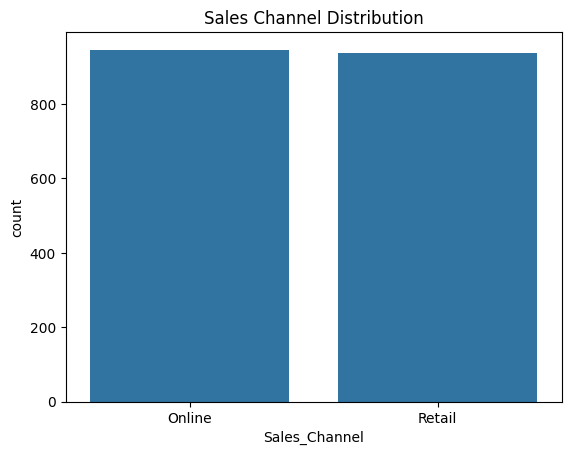

In [109]:
sns.countplot(x='Sales_Channel', data=df)

plt.title("Sales Channel Distribution")

plt.show()

<h4 style="color:yellow;"> Insight: </h4>
The visualization shows the frequency of sales across different channels. The channel with the highest bar represents the most commonly used purchasing platform.

#### 2️⃣ Units Sold Distribution #### 
Aim: To understand how the number of units sold is distributed across orders.

Structure:
X-axis: Units_Sold
Y-axis: Frequency

Chart Type: Histogram

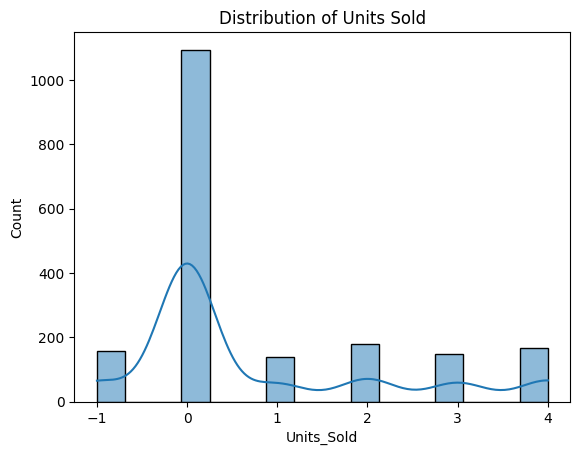

In [110]:
sns.histplot(df['Units_Sold'], kde=True)

plt.title("Distribution of Units Sold")

plt.show()

<h4 style="color:yellow;"> Insight: </h4>
The histogram shows the distribution of units sold per order. It helps identify common purchase quantities and detect unusually large or small orders.

#### 3️⃣ Product Line Distribution ####
Aim: To determine which product lines appear most frequently in the dataset.

Structure: 
X-axis: Product_Line
Y-axis: Count of Products

Chart Type: Bar Chart

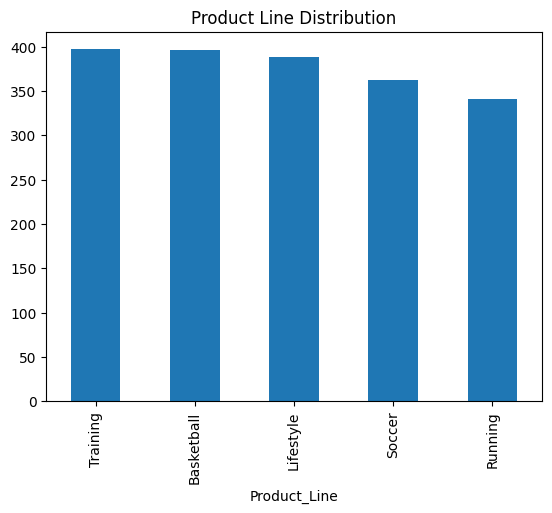

In [111]:
df['Product_Line'].value_counts().plot(kind='bar')

plt.title("Product Line Distribution")

plt.show()

<h4 style="color:yellow;"> Insight: </h4>
This visualization highlights the most common product categories. Product lines with higher counts indicate greater product availability or demand.

<h2 style="color:green;"> 📊 2. Bivariate Analysis </h2> 

#### 1️⃣ Revenue vs Profit ####
Aim: To examine the relationship between revenue generated and profit earned.

Structure
X-axis: Revenue
Y-axis: Profit

Chart Type: Scatter Plot

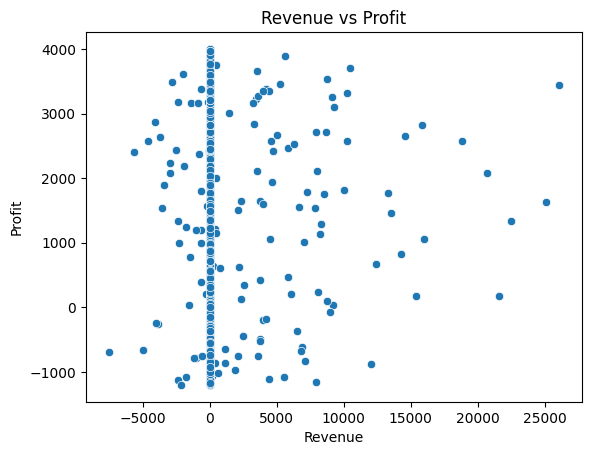

In [112]:
sns.scatterplot(x='Revenue', y='Profit', data=df)

plt.title("Revenue vs Profit")

plt.show()

<h4 style="color:yellow;"> Insight: </h4>
The scatter plot shows how profit changes with revenue. A positive trend suggests that higher revenue generally leads to higher profit.

#### 2️⃣ Product Line vs Average MRP ####
Aim: To compare average product prices across different product lines.

Structure:;
X-axis: Product_Line
Y-axis: Average MRP

Chart Type: Bar Chart

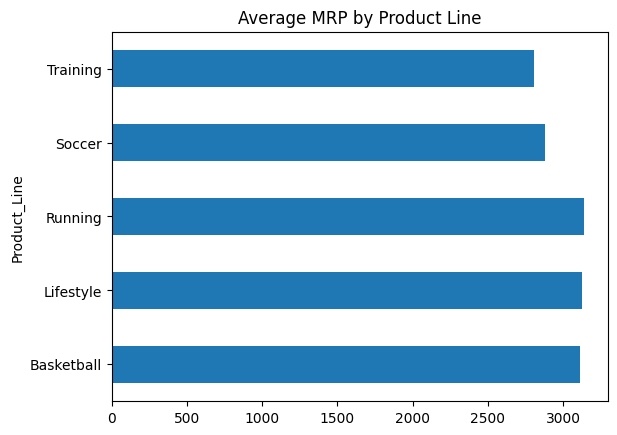

In [136]:
avg_mrp = df.groupby('Product_Line')['MRP'].mean()

avg_mrp.plot(kind='barh')

plt.title("Average MRP by Product Line")

plt.show()

<h4 style="color:yellow;"> Insight: </h4>
The chart shows which product lines have higher pricing. Premium categories usually have higher average MRPs.

<h2 style="color:green;">📊 3. Multivariate Analysis </h2>

#### 1️⃣ Pairplot of Sales Variables ####
Aim: To analyze relationships among multiple numerical variables.

Structure:
Variables: Units_Sold, MRP, Revenue, Profit

Chart Type: Pairplot

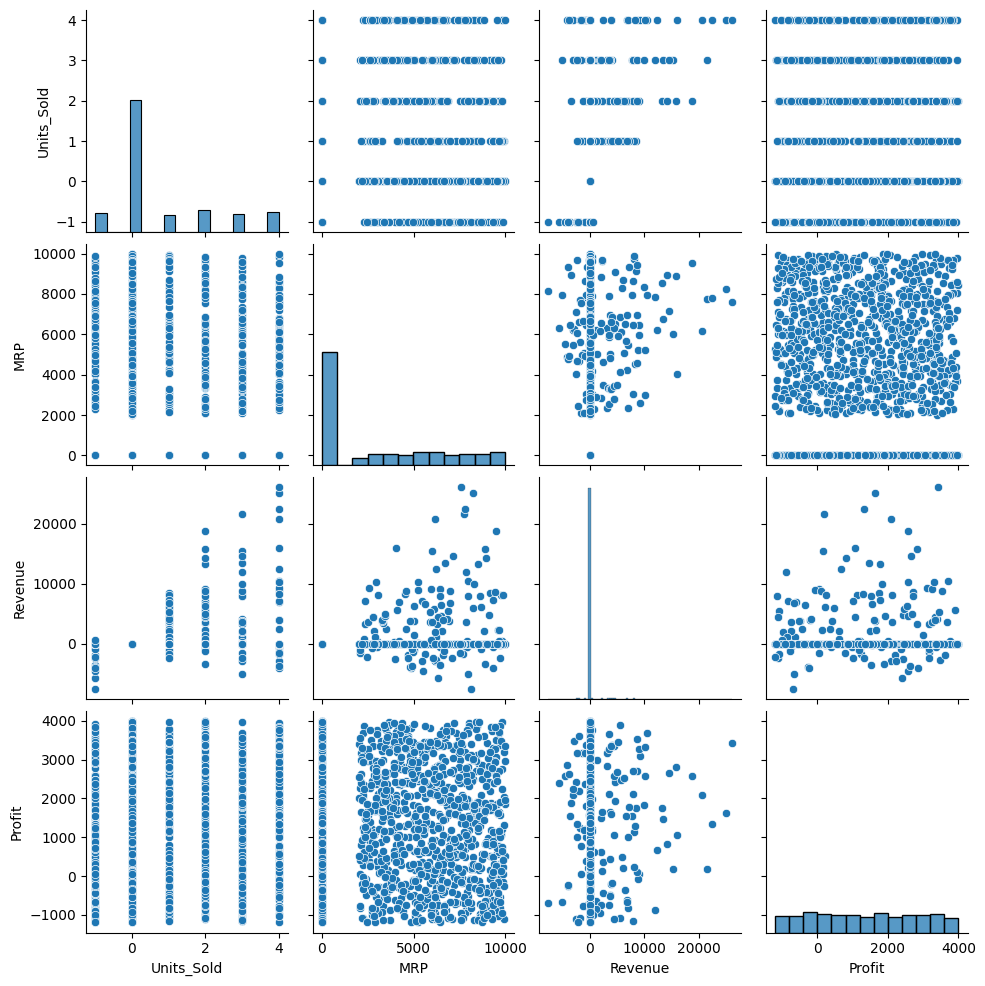

In [115]:
sns.pairplot(df[['Units_Sold','MRP','Revenue','Profit']])

plt.show()

<h4 style="color:yellow;"> Insight: </h4>
This plot reveals correlations between multiple variables and helps identify patterns such as how pricing influences revenue and profit.

#### 3️⃣ Revenue by Region and Sales Channel ####
Aim:
To examine how revenue varies across regions and sales channels.

Structure:
X-axis: Region
Y-axis: Revenue
Hue: Sales_Channel

Chart Type: Grouped Bar Chart

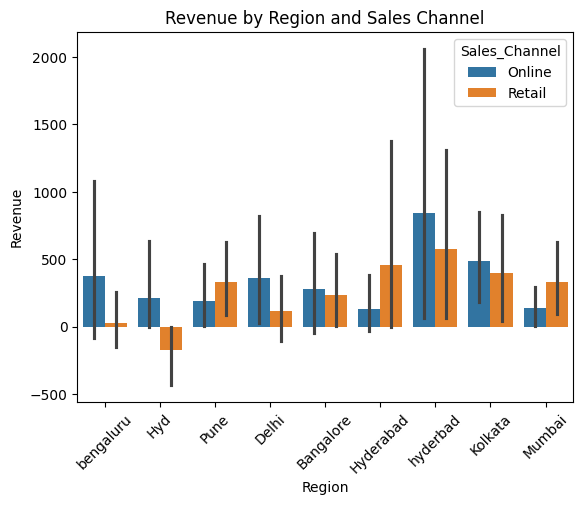

In [117]:
sns.barplot(x='Region', y='Revenue', hue='Sales_Channel', data=df)

plt.title("Revenue by Region and Sales Channel")

plt.xticks(rotation=45)

plt.show()

<h4 style="color:yellow;"> Insight: </h4>
This visualization shows which regions and sales channels contribute the most to revenue generation.

<h2 style="color:green;"> 📊 4. Temporal Analysis </h2>

Monthly Profit Trend
Aim

To track profit changes over time.

Structure

X-axis: Product Order 

Y-axis: Profit

Chart Type: Line Chart

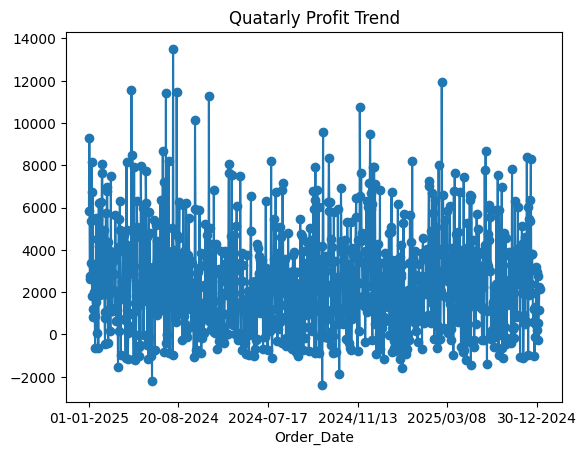

In [129]:
Quatarly_profit = df.groupby('Order_Date')['Profit'].sum()

Quatarly_profit.plot(kind='line', marker='o')

plt.title("Quatarly Profit Trend")

plt.show()

#### 2️⃣ Units Sold Over Time ####
Aim:
To observe changes in product demand over time.

Structure:
X-axis: Product sold
Y-axis: Month

Chart Type: Line Chart

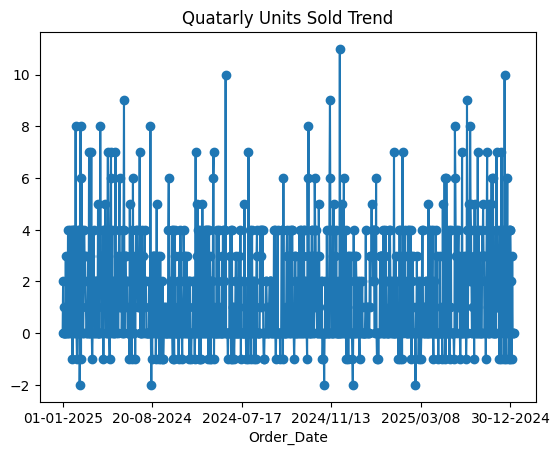

In [132]:
Quatarly_units = df.groupby('Order_Date')['Units_Sold'].sum()

Quatarly_units.plot(kind='line', marker='o')

plt.title("Quatarly Units Sold Trend")

plt.show()

<h4 style="color:yellow;"> Insight: </h4>
This visualization helps identify periods with high customer demand and potential seasonal buying patterns

<H2> 📋 Final Insight </H2>

Overall, the analysis shows that sales performance is driven by a combination of product pricing, customer segments, and sales channels, where higher-priced products and increased units sold contribute directly to higher revenue and profit. Additionally, discount strategies and channel distribution significantly influence purchasing behavior, while temporal trends highlight consistent patterns in sales growth. This indicates that optimizing pricing, targeting the right customer groups, and focusing on high-performing sales channels can greatly improve overall business performance.

<h2> ✏️ EDA Summary </h2>

The Exploratory Data Analysis of the sales dataset from Nike provided valuable insights into product performance, customer purchasing behavior, and sales trends.

From the Univariate Analysis, it was observed that the dataset contains varied distributions of sales channels, product lines, and units sold. These visualizations helped understand the overall structure and frequency distribution of individual variables.

The Bivariate Analysis revealed relationships between variables such as revenue, profit, discounts, and product pricing. The results indicated that higher revenue generally leads to higher profit, although discounts and pricing strategies can influence profitability.

Through Multivariate Analysis, interactions between multiple variables such as units sold, MRP, revenue, and profit were examined. Correlation analysis showed how different factors collectively influence sales performance and profitability.

The Temporal Analysis provided insights into time-based sales patterns. Monthly trends in revenue, profit, and units sold helped identify seasonal fluctuations and peak sales periods.

Overall, the EDA helped uncover meaningful patterns and relationships within the dataset. These insights can support better decision-making in areas such as pricing strategy, marketing focus, product management, and sales channel optimization.

<h2> 📃 Conclusion </h2>

This project analyzed the sales dataset of Nike using Python data analysis techniques in Visual Studio Code. The dataset was first cleaned and preprocessed to handle missing values, remove duplicates, and ensure proper data formatting. Exploratory Data Analysis (EDA) was then conducted using various visualization techniques to understand sales patterns and relationships between different variables.

The analysis revealed important insights about product pricing, sales channel performance, and customer purchasing behavior. It was observed that revenue and profit are closely related, while discounts play a significant role in influencing sales outcomes. Additionally, the distribution of sales across different channels and product lines highlighted key areas that contribute most to overall business performance.Overall, the project demonstrates how data analysis can be used to transform raw data into meaningful insights for better decision-making.